In [1]:
import pandas as pd 
import numpy as np 
import os 

In [2]:
# Checking one file 
df = pd.read_csv("data/DL001.csv", encoding='latin1')
df.columns

Index(['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)',
       'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)',
       'Ozone (ug/m3)', 'Benzene (ug/m3)'],
      dtype='str')

In [5]:
# Select required columns
use_cols = ['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)',
       'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)',
       'Ozone (ug/m3)', 'Benzene (ug/m3)']

In [8]:
# Load and Combine all files
folder_path = "data/"
files = os.listdir(folder_path)

dfs = []

for file in files:
    if file.endswith(".csv"):
        path = os.path.join(folder_path, file)

        try:
            df = pd.read_csv(path, encoding='latin1')

            # Clean column names (VERY IMPORTANT)
            df.columns = df.columns.str.strip()

            # Select only needed columns (safe way)
            cols_to_keep = [col for col in df.columns if col in [
                'From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)',
                'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)',
                'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)'
            ]]

            df = df[cols_to_keep]

            df['State'] = file[:2]
            df['Station_ID'] = file.replace(".csv", "")

            dfs.append(df)

        except Exception as e:
            print(f"Error in {file}: {e}")

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),Benzene (ug/m3),State,Station_ID
0,2010-01-01 00:00:00,2010-01-01 01:00:00,NaN,NaN,21.02,41.00,38.75,NaN,4.27,4.43,3.0,NaN,DL,DL001
1,2010-01-01 01:00:00,2010-01-01 02:00:00,NaN,NaN,9.12,29.50,23.25,NaN,4.55,3.69,3.5,NaN,DL,DL001
2,2010-01-01 02:00:00,2010-01-01 03:00:00,NaN,NaN,10.48,27.25,23.25,NaN,4.62,3.68,3.5,NaN,DL,DL001
3,2010-01-01 03:00:00,2010-01-01 04:00:00,NaN,NaN,6.50,24.25,18.25,NaN,4.52,3.11,4.0,NaN,DL,DL001
4,2010-01-01 04:00:00,2010-01-01 05:00:00,NaN,NaN,5.75,21.50,16.25,NaN,4.70,2.80,4.0,NaN,DL,DL001


In [9]:
# Save combined dataset 
combined_df.to_csv("combined.csv", index=False)

In [10]:
# Reload data + Sample (for speed)
df = pd.read_csv("combined.csv")
df = df.sample(5000)   # makes everything fast

In [11]:
# Rename columns
df.columns = ['From_Date', 'To_Date', 'PM25', 'PM10',
              'NO', 'NO2', 'NOx', 'NH3',
              'SO2', 'CO', 'Ozone', 'Benzene',
              'State', 'Station_ID']

In [12]:
# Handle date 
df['From_Date'] = pd.to_datetime(df['From_Date'], errors='coerce')

df['Year'] = df['From_Date'].dt.year
df['Month'] = df['From_Date'].dt.month

In [13]:
# Clean data 
df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

,From_Date,To_Date,PM25,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,State,Station_ID,Year,Month
506853,2014-11-06 10:00:00,2014-11-06 11:00:00,94.500000,162.963882,6.870000,7.750000,20.980000,20.310000,2.250000,8.250000,30.790974,3.387986,DL,DL005,2014,11
3389575,2020-02-17 23:00:00,2020-02-18 00:00:00,85.904428,40.560000,29.154399,36.955097,33.790000,33.274829,45.690000,1.480000,30.790974,3.387986,MH,MH003,2020,2
1828642,2017-12-03 19:00:00,2017-12-03 20:00:00,85.904428,162.963882,29.154399,167.550000,49.347147,33.274829,12.100000,1.358954,36.740000,17.990000,DL,DL018,2017,12
2194773,2018-05-31 14:00:00,2018-05-31 15:00:00,47.000000,185.000000,0.640000,9.410000,10.060000,41.420000,4.420000,0.740000,169.240000,0.740000,DL,DL026,2018,5
3980752,2021-05-31 05:00:00,2021-05-31 06:00:00,19.360000,60.700000,14.170000,35.660000,49.830000,16.970000,7.040000,0.430000,4.710000,4.900000,MH,MH015,2021,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3194818,2011-02-28 02:00:00,2011-02-28 03:00:00,85.904428,162.963882,29.154399,36.955097,49.347147,33.274829,13.430741,1.358954,30.790974,3.387986,MH,MH002,2011,2
2274958,2022-05-27 01:00:00,2022-05-27 02:00:00,108.250000,208.500000,3.250000,59.620000,34.350000,46.520000,8.400000,1.358954,18.300000,0.470000,DL,DL027,2022,5
2729356,2020-05-18 21:00:00,2020-05-18 22:00:00,91.500000,198.000000,2.480000,27.450000,16.620000,14.000000,17.100000,1.080000,25.550000,3.387986,DL,DL038,2020,5
624006,2014-12-19 19:00:00,2014-12-19 20:00:00,85.904428,162.963882,10.750000,28.250000,23.500000,34.500000,13.430741,1.358954,17.250000,3.387986,DL,DL006,2014,12


In [14]:
# Optimize speed 
df['State'] = df['State'].astype('category')
df['Station_ID'] = df['Station_ID'].astype('category') 

In [15]:
# EDA 
import matplotlib.pyplot as plt
import seaborn as sns

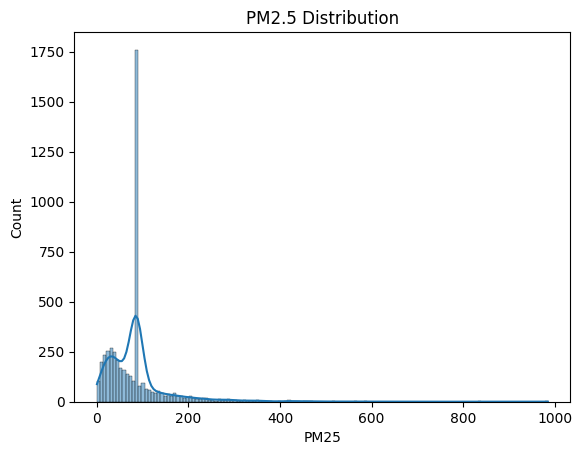

In [17]:
# PM2.5 distribution 
sns.histplot(df['PM25'], kde=True)
plt.title("PM2.5 Distribution")
plt.show()

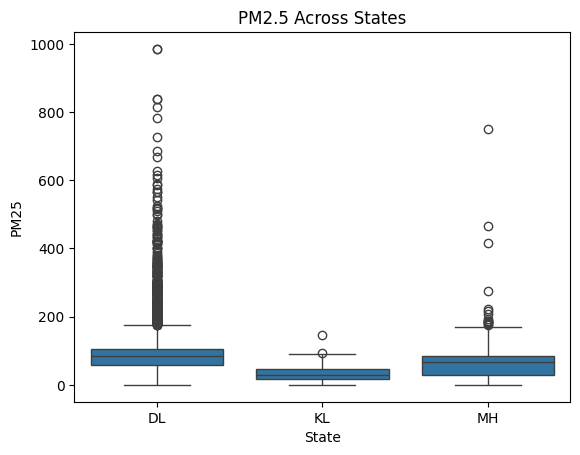

In [18]:
# State comparison
sns.boxplot(x='State', y='PM25', data=df)
plt.title("PM2.5 Across States")
plt.show()

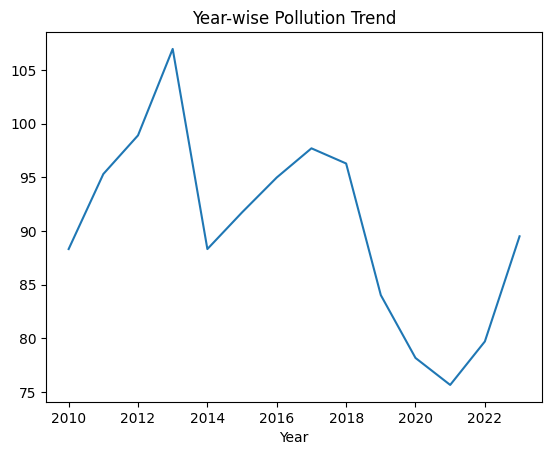

In [19]:
# Year-wise trend
df.groupby('Year')['PM25'].mean().plot()
plt.title("Year-wise Pollution Trend")
plt.show()

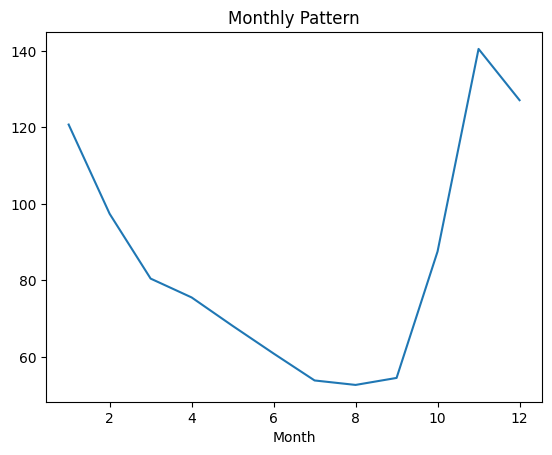

In [20]:
# Monthly pattern 
df.groupby('Month')['PM25'].mean().plot()
plt.title("Monthly Pattern")
plt.show()

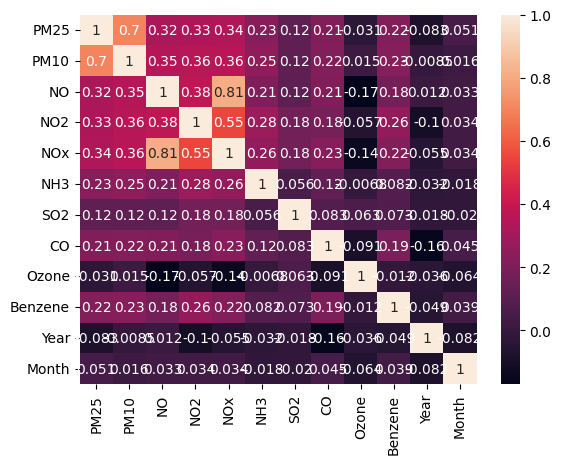

In [21]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

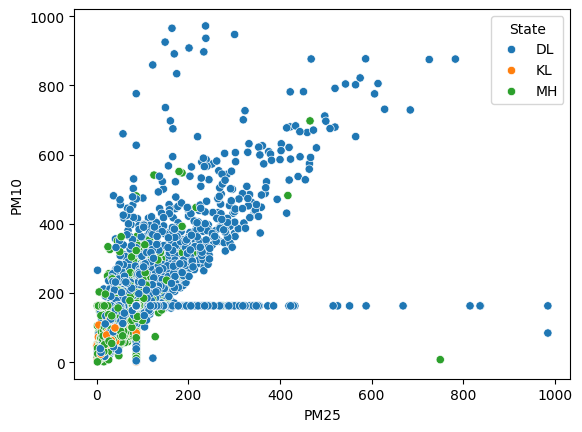

In [22]:
# Scatter plot 
sns.scatterplot(x='PM25', y='PM10', hue='State', data=df)
plt.show()

In [23]:
# Outlier detection 
Q1 = df['PM25'].quantile(0.25)
Q3 = df['PM25'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['PM25'] < Q1 - 1.5*IQR) |
              (df['PM25'] > Q3 + 1.5*IQR)]

print("Outliers:", outliers.shape) 

Outliers: (507, 16)


In [24]:
# Final clean data 
df.to_csv("final_cleaned.csv", index=False)